##**[9주차]실습**
- 아래의 실습1), 실습2), 실습3)에서 코드를 완성하시오.
- colab 사용 시, 빠른 실습 진행을 위해 GPU 사용 설정이 필요합니다. (런타임 유형->T4 GPU 사옹)

In [1]:
print("2353881, 최대영")

2353881, 최대영


In [2]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

tigers7101@gmail.com


In [3]:
# google drive 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install beautifulSoup4

In [5]:
!pip install finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.6 MB/s eta 0:00:00


###**예제 1) 데이터를 잘라서 샘플을 작성해본다.**
- **[실습목표]** 삼성의 실제 주식 데이터를 사용하여 순환신경망의 학습에 사용할 수 있는 샘플을 제작해본다.

####**실습 1-1)**
  - 데이터를 다운로드하고 그래프로 그려본다.

In [6]:
# 라이브러리 import
import FinanceDataReader as fdr
import numpy as np
import matplotlib.pyplot as plt

# 삼성전자 코드='005930', 2020년부터 '2021-03-08'까지의 데이터 다운로드
'''이곳에 코드를 작성하시오''' # fdr.DataReader 함수 입력 형태 -> fdr.DataReader(삼성전자 코드, 시작기간, 끝기간)
samsung = fdr.DataReader('005930', '2020')

# 삼성전자 데이터세트의 head 출력
print(samsung.head())

             Open   High    Low  Close    Volume    Change
Date                                                      
2020-01-02  55500  56000  55000  55200  12993228 -0.010753
2020-01-03  56000  56600  54900  55500  15422255  0.005435
2020-01-06  54900  55600  54600  55500  10278951  0.000000
2020-01-07  55700  56400  55600  55800  10009778  0.005405
2020-01-08  56200  57400  55900  56800  23501171  0.017921


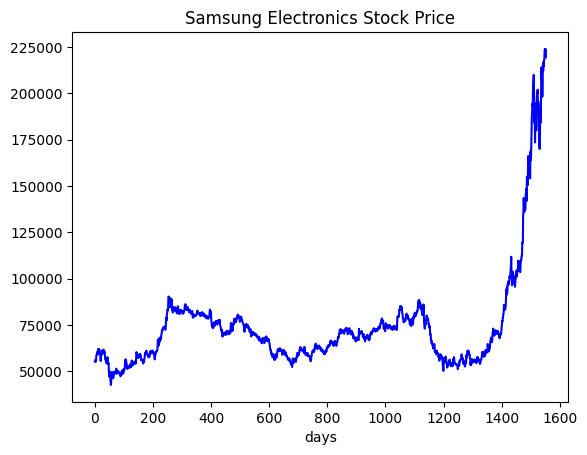

In [11]:
# 시작가만 취한다.
seq_data = (samsung[['Open']]).to_numpy()

# 데이터를 선형 그래프로 그린다.
plt.plot(seq_data, color='blue')
plt.title("Samsung Electronics Stock Price")
plt.xlabel("days")
plt.show()

####**실습 1-2)**
  - 데이터를 잘라서 샘플을 생성해본다.

In [14]:
# 위에서 load 한 데이터셋으로 학습 데이터셋을 들어 출력한다.
def make_sample(data, window):
    train = []
    target = []
    for i in range(len(data)-window): # 데이터의 길이만큼 반복
      train.append(data[i:i+window]) # iqnxj (i+window-1)까지를 저장
      target.append(data[i+window]) # (i+window) 번째 요소는 정답
    return np.array(train), np.array(target) # 훈련 샘플과 정답 레이블 반환

X, y = make_sample(seq_data, 7) # 윈도우 크기 = 7
print(X.shape, y.shape) # 넘파이 배열의 형상 출력
print(X[0], y[0]) # 첫 번째 샘플 출력

(1546, 7, 1) (1546, 1)
[[55500]
 [56000]
 [54900]
 [55700]
 [56200]
 [58400]
 [58800]] [59600]


###**예제 2) 사인파 예측 프로그램**
- **[실습목표]** 사인파 정보로 학습 데이터를 생성하고, 생성한 데이터로 학습 및 예측을 수행해본다.


In [15]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [16]:
# 사인파 학습을 위한 데이터세트를 생성한다.
seq_data = []
for i in np.arange(0, 1000):
    seq_data += [[np.sin( np.pi * i * 0.01)]]
X, y = make_sample(seq_data, 10)

In [17]:
# model을 선언한다.
model = Sequential()
model.add(SimpleRNN(10, activation='tanh', input_shape=(10, 1)))
model.add(Dense(1, activation='tanh'))
model.compile(optimizer='adam', loss='mse')

history = model.fit(X, y, epochs=100, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.2669
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0730
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0323
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0240
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0214
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0198
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0184
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0170
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0154
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0136
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0120
Epoch 12/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0105
Epoch 13/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0094
Epoch 14/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0084
Epoch 15/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0077
Epo

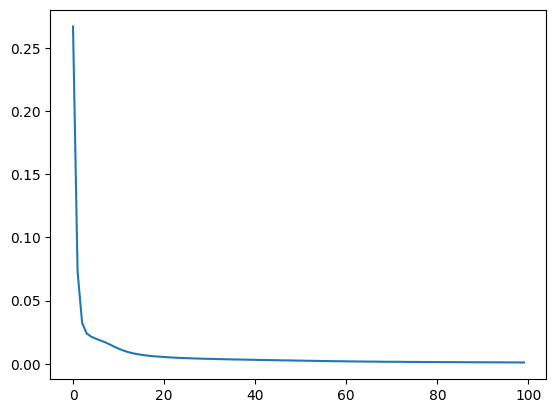

In [18]:
# loss 그래프를 출력한다.
'''이곳에 코드를 작성하시오'''
plt.plot(history.history['loss'], label="loss")
plt.show()

In [ ]:
# 실제 데이터와 예측한 데이터의 값을 함께 그래프로 출력한다.
y_pred = '''이곳에 코드를 작성하시오'''
'''이곳에 코드를 작성하시오 (예측값 그래프)'''
'''이곳에 코드를 작성하시오 (실제값 그래프)'''
plt.show()

###**예제 3) Keras를 이용한 주가 예측**
- **[실습목표]** 예제 1에서 생성한 것과 같이 삼성의 주가 데이터를 학습데이터로 작성하고, 데이터를 기반으로 주가를 예측하는 모델을 구축한다.

In [20]:
import FinanceDataReader as fdr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
# 2016년 부터 2021년까지의 데이터를 load 한다.
samsung = fdr.DataReader('005930', '2016')
print(samsung)

              Open    High     Low   Close    Volume    Change
Date                                                          
2016-01-04   25200   25200   24100   24100    306939 -0.043651
2016-01-05   24040   24360   23720   24160    216002  0.002490
2016-01-06   24160   24160   23360   23500    366752 -0.027318
2016-01-07   23320   23660   23020   23260    282388 -0.010213
2016-01-08   23260   23720   23260   23420    257763  0.006879
...            ...     ...     ...     ...       ...       ...
2026-04-23  223000  229500  216000  224500  34525485  0.032184
2026-04-24  224000  225000  216500  219500  19626666 -0.022272
2026-04-27  220000  226000  218500  224500  22870374  0.022779
2026-04-28  224000  226000  221500  222000  18444490 -0.011136
2026-04-29  219500  222000  218500  220250   5699351 -0.007883

[2532 rows x 6 columns]


In [21]:
# 시작가 만을 openValue에 입력한다.
openValues = samsung[['Open']]

In [22]:
# 특징값 정규화
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range= (0, 1))
scaled = scaler.fit_transform(openValues)

In [23]:
# 훈련 데이터와 테스트 데이터의 분리
TEST_SIZE = 200
train_data = scaled[:-TEST_SIZE]
test_data = scaled[-TEST_SIZE:]


In [24]:
# 순차 훈련 데이터를 생성한다.
X_train, y_train = make_sample(train_data, 30)

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [26]:
# LSTM 구축하기
model = Sequential()
model.add(LSTM(16,
               input_shape=(X_train.shape[1], 1),
               activation='tanh',
               return_sequences=False))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
# 모델 학습
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(X_train, y_train, epochs = 100, batch_size = 16)

Epoch 1/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0049
Epoch 2/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.4628e-04
Epoch 3/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.8169e-04
Epoch 4/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.7270e-04
Epoch 5/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6203e-04
Epoch 6/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5966e-04
Epoch 7/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5565e-04
Epoch 8/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5171e-04
Epoch 9/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.4791e-04
Epoch 10/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.4543e-04
Epoch 11/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.4378e-04
Epoch 12/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3682e-04
Epoch 13/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3930e-04
Epoch 14/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.

In [28]:
# 테스트셋을 이용하여 미래 주가 예측
X_test, y_test = make_sample(test_data, 30)
pred = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


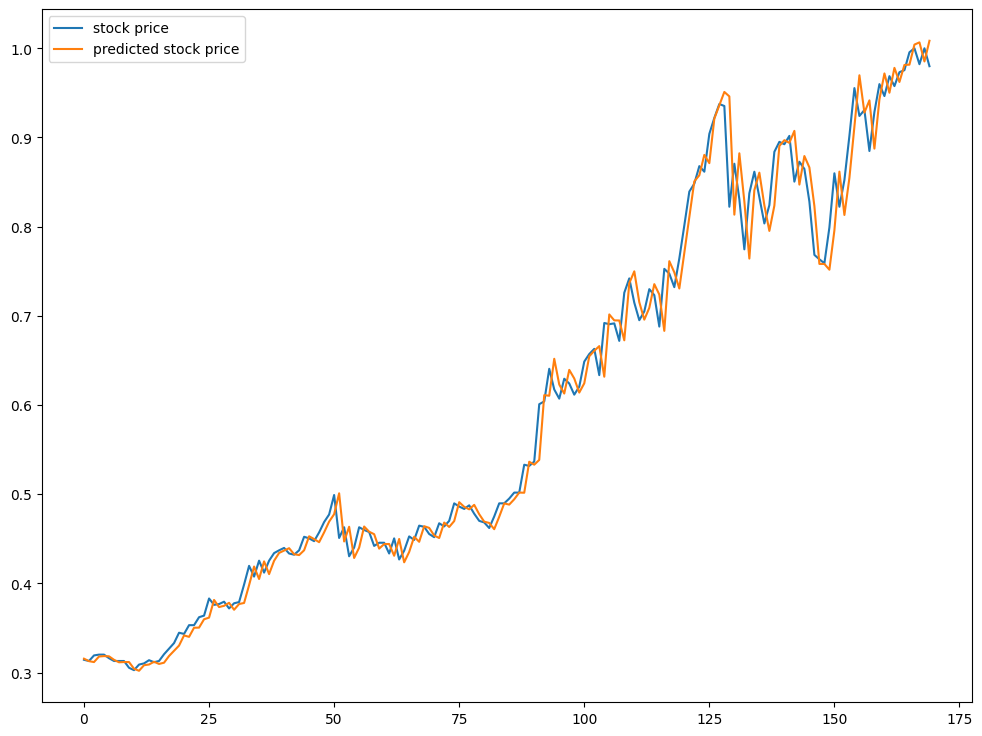

In [29]:
# 그래프 그리기
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 9))
plt.plot(y_test, label='stock price')
plt.plot(pred, label='predicted stock price')

plt.legend()
plt.show()